# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

According to the Materials and Methods section, the number of marketing campaigns that the data represents is 17 , the exact exceprt is "The dataset collected is related to 17 campaigns that
occurred between May 2008 and November 2010,
corresponding to a total of 79354 contacts."

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder


In [164]:
# Uploaded to direct location in collab (data/bank-additional/)
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [165]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [167]:
# Change y feature name to a meaningful name of termdeposit
df.rename(columns = {'y': 'termdeposit'}, inplace = True)

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [169]:
#clearly state the Business Objective of the task.
# Before we do that lets understand the data

In [170]:
numeric_df = df.select_dtypes(include=['number'])
display(numeric_df.head())

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0


In [171]:
# Is the data Clean data  ie are there any nulls
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [172]:
# using poltly lets plot the most imports data from numerical columns
fig = px.box(numeric_df, points="all")
fig.show()

In [173]:
# Lets get some value counts of of customers that said yes to termdeposit
df['termdeposit'].value_counts()

,count
termdeposit,
no,36548
yes,4640


In [174]:
# Let's do a bar plot of customer count that said yes to termdeposit
termdeposit_counts = df['termdeposit'].value_counts().reset_index()
termdeposit_counts.columns = ['termdeposit', 'count'] # Rename columns for clarity
px.bar(termdeposit_counts, x="termdeposit", y="count", title="Customer Count that said yes to termdeposit")

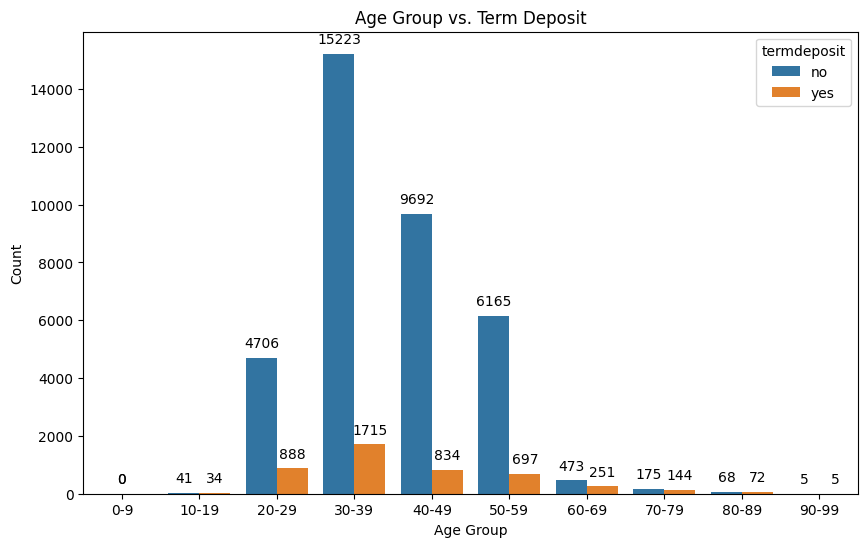

In [175]:

# Create age groups in 10-year intervals
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# How about a bar chart of age groups and whose term deposit is yes or no
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='termdeposit', order=labels)
plt.title('Age Group vs. Term Deposit')
plt.xlabel('Age Group')
plt.ylabel('Count')
# At the top of each bar lets show the count as well
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

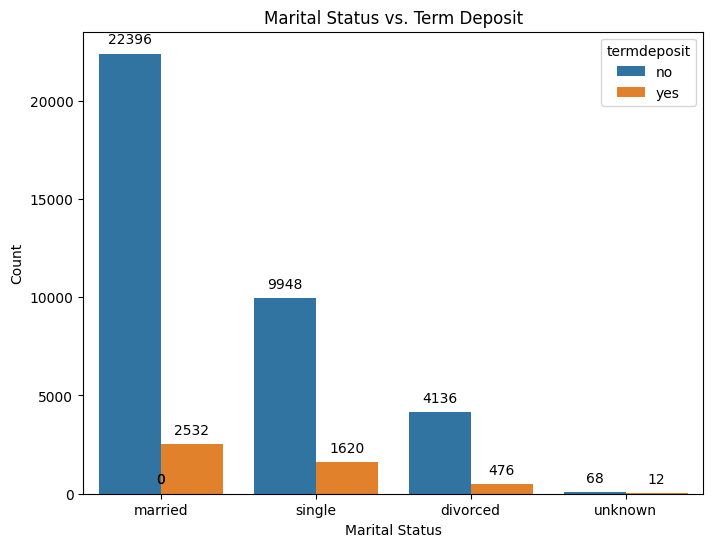

In [176]:


# How about bar chart of marital status and whose term deposit is yes or no
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='marital', hue='termdeposit')
plt.title('Marital Status vs. Term Deposit')
plt.xlabel('Marital Status')
plt.ylabel('Count')
# At the top of each bar lets show the count as well
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

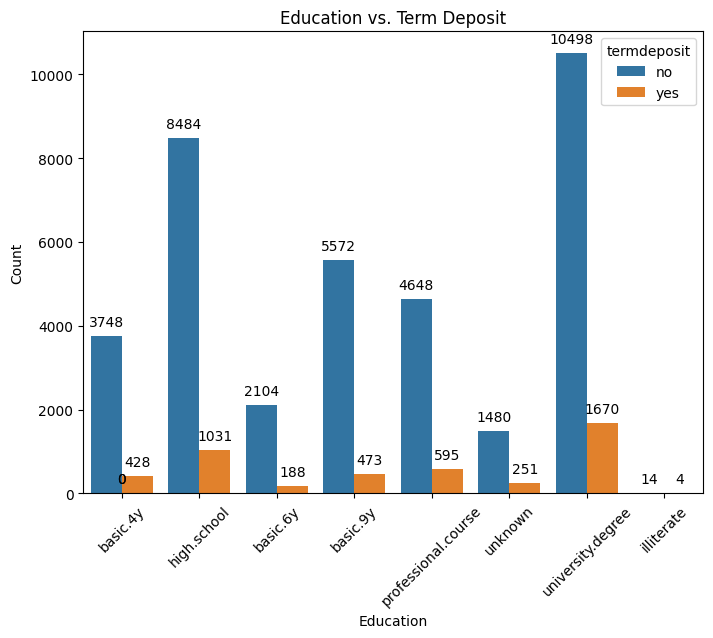

In [177]:
# How about bar chart of education  and whose term deposit is yes or no
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='education', hue='termdeposit')
plt.title('Education vs. Term Deposit')
plt.xlabel('Education')
# Turn xlable by 45 degrees
plt.xticks(rotation=45)
plt.ylabel('Count')
# At the top of each bar lets show the count as well
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

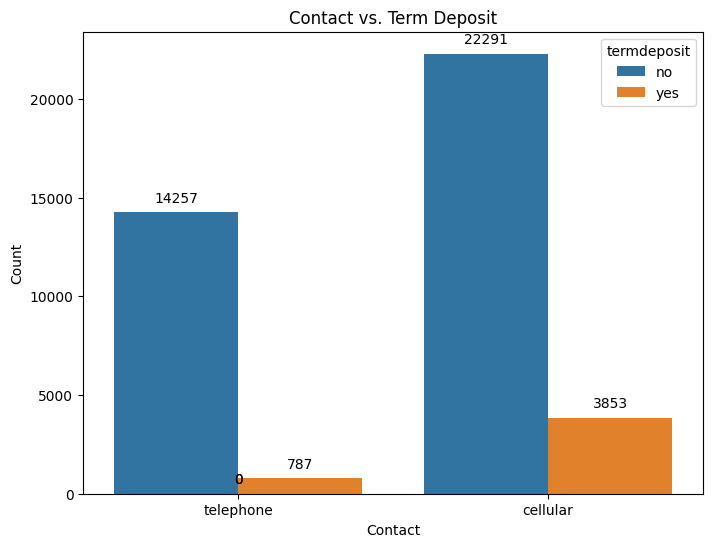

In [178]:
# How about bar chart of contact  and whose term deposit is yes or no
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='contact', hue='termdeposit')
plt.title('Contact vs. Term Deposit')
plt.xlabel('Contact')
plt.ylabel('Count')
# At the top of each bar lets show the count as well
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

In [179]:
# Lets get value counts of contact for both telephone and cellular and which said yes or no
df.groupby(['contact', 'termdeposit']).size()



contact    termdeposit
cellular   no             22291
           yes             3853
telephone  no             14257
           yes              787
dtype: int64

In [180]:
# Lets get the percentage of each yes or no option per group
df.groupby(['contact', 'termdeposit']).size() / df.groupby(['contact']).size()

contact    termdeposit
cellular   no             0.852624
           yes            0.147376
telephone  no             0.947687
           yes            0.052313
dtype: float64

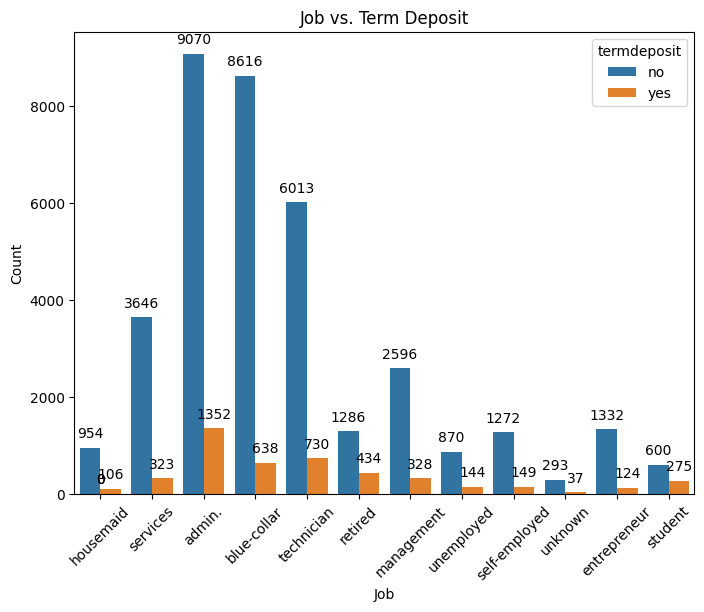

In [181]:
# How about bar chart of job  and whose term deposit is yes or no
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='job', hue='termdeposit')
plt.title('Job vs. Term Deposit')
plt.xlabel('Job')
# Turn xlable by 45 degrees
plt.xticks(rotation=45)
plt.ylabel('Count')
# At the top of each bar lets show the count as well
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

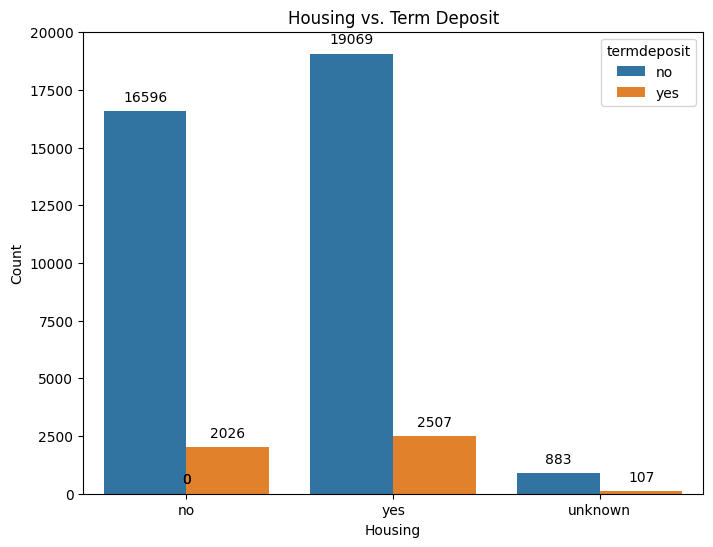

In [182]:
# How about bar chart of housing  and whose term deposit is yes or no
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='housing', hue='termdeposit')
plt.title('Housing vs. Term Deposit')
plt.xlabel('Housing')
plt.ylabel('Count')
# At the top of each bar lets show the count as well
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

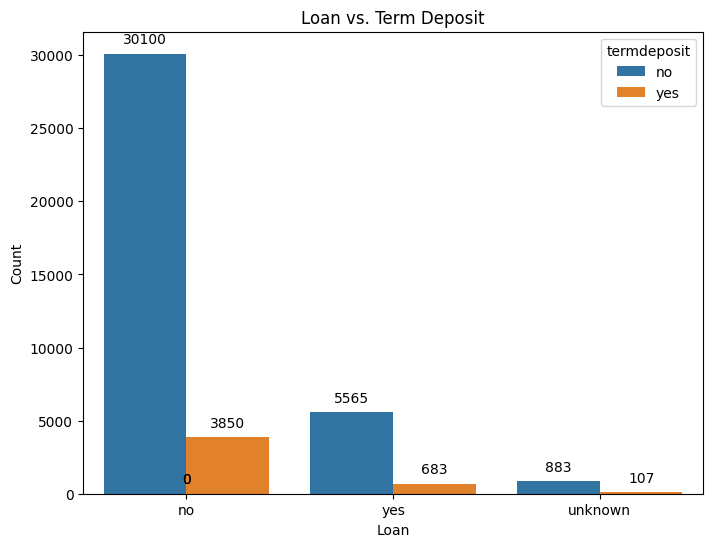

In [183]:
# How about bar chart of loan  and whose term deposit is yes or no
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='loan', hue='termdeposit')
plt.title('Loan vs. Term Deposit')
plt.xlabel('Loan')
plt.ylabel('Count')
# At the top of each bar lets show the count as well
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

In [184]:
# We can build a model using feature 1 - 7


After Reviewing the plots with various factors it is clear that marketing campaign had the following Observations:

Education - for the termdeposit the bank was successul to seel the product to university degree folks

Job - for the term deposit the bank wbank had the most success with folks in admin role,followed by Technician and then blue-collar

Marital Status - for the termdeposit the bank was successful to sell the product to married vs single

Housing - Not significat difference between customers have mortagage loan or not

Contact - For the termdeposit the bank was successful to sell the product to cellphone users vs telephone users

Clearly state the Business Objective of the task. State the objective below.

> The campaigns show some success in some categories but the results doesn't seem to be too successful.

From a business objective, of the task is to determine the factors could lead to a higher success rate, for example,

The business goal is to identify the factors that lead to a higher campaign success rate. including factors like housing mortgage, contact method (cell phone, telephone), personal loans, age , job, university degree etc.



### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [185]:
# As we are using 7 features so lets extract the data for these.
X = df[['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact']]
y = df['termdeposit']

X.head(10)

,job,marital,education,default,housing,loan,contact
0,housemaid,married,basic.4y,no,no,no,telephone
1,services,married,high.school,unknown,no,no,telephone
2,services,married,high.school,no,yes,no,telephone
3,admin.,married,basic.6y,no,no,no,telephone
4,services,married,high.school,no,no,yes,telephone
5,services,married,basic.9y,unknown,no,no,telephone
6,admin.,married,professional.course,no,no,no,telephone
7,blue-collar,married,unknown,unknown,no,no,telephone
8,technician,single,professional.course,no,yes,no,telephone
9,services,single,high.school,no,yes,no,telephone


In [186]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   job        41188 non-null  object
 1   marital    41188 non-null  object
 2   education  41188 non-null  object
 3   default    41188 non-null  object
 4   housing    41188 non-null  object
 5   loan       41188 non-null  object
 6   contact    41188 non-null  object
dtypes: object(7)
memory usage: 2.2+ MB


Lets Use ColumnTransformer to  apply data preparation transforms to data and category columns

In [187]:


cl_t = make_column_transformer((OneHotEncoder(handle_unknown='ignore'),
                                        ['job', 'marital', 'education','default','contact']),
                                      (OrdinalEncoder(), ['housing','loan']),
                                      remainder='passthrough')
cl_t.fit(X)

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'default',
                                  'contact']),
                                ('ordinalencoder', OrdinalEncoder(),
                                 ['housing', 'loan'])])

In [188]:

# Lets work to encode the y ie termdeposit
le_y = LabelEncoder().fit_transform(y)
le_y

array([0, 0, 0, ..., 0, 1, 0])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [189]:

X_train, X_test, y_train, y_test = train_test_split(X, le_y, test_size=0.2, random_state=42)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [190]:
%%time
# Lets build a good  baseline model using stard baseline methods

dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
y_pred = dummy_clf.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred)



CPU times: user 5.06 ms, sys: 8 µs, total: 5.07 ms
Wall time: 5.12 ms


In [191]:
# As the Baseline accuracy of dummy classifier is 1 lets print the classification report
from sklearn.metrics import classification_report
# print the results of baseline model
print(f"Baseline Accuracy: {baseline_accuracy:.9f}")
print(classification_report(y_test, y_pred))


Baseline Accuracy: 0.886501578
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7303
           1       0.00      0.00      0.00       935

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Baseline model accuracy is 0.89 , This shows extreme imbalance in the data. This is not a good sign , so lets try something else.

Even the precision recall and f1-score is 0.79,0.89 and 0.83 respectively , showcasing that the imbalance in the data.

Thinking more about is may be I should use a different baseline model with default parameters

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [192]:
%%time
# As the Dummyclassifier baseline showed extreme imbalance in the data, so lets see if we can use a differet model for baseline
# Let create a linearregression model with default parameters and set that as baseline

lr_pipe = Pipeline ([
    ('transformer', cl_t),
    ('scale', StandardScaler(with_mean=False)),
    ('model', LogisticRegression())
])
# Train the classifiers
lr = lr_pipe.fit(X_train, y_train)

lr_train_score = lr.score(X_train, y_train)
print("Training Accuracy LR", lr_train_score)
lr_test_score = lr.score(X_test, y_test)
print("Tes Accuracy LR", lr_train_score)

# use the model to predict the class labels of the test set:
lr_predict = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predict)


Training Accuracy LR 0.8875265553869499
Tes Accuracy LR 0.8875265553869499
CPU times: user 439 ms, sys: 2.69 ms, total: 441 ms
Wall time: 306 ms


In [193]:
# print the results of baseline model
print(f"Logistic Regression Accuracy: {lr_accuracy:.9f}")
print(classification_report(y_test, lr_predict))

Logistic Regression Accuracy: 0.886501578
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7303
           1       0.00      0.00      0.00       935

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



### Problem 9: Score the Model

What is the accuracy of your model?

In [194]:
print(f"Logistic Regression Accuracy: {lr_accuracy:.9f}")
print(f"Baseline Accuracy: {baseline_accuracy:.9f}")

Logistic Regression Accuracy: 0.886501578
Baseline Accuracy: 0.886501578


Due to highly imbalanced classes the accuracy of the Base-line model and Linear regression model is very similar.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [195]:
%%time

# Lets work with KNN Model

knn_pipe = Pipeline ([
    ('transformer', cl_t),
    ('scale', StandardScaler(with_mean=False)),
    ('model', KNeighborsClassifier())
])

# Train the classifiers and predict
knn = knn_pipe.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

# Evaluate the scores

knn_train_score = knn.score(X_train, y_train)
print("Training Accuracy KNN", knn_train_score)

knn_test_score = knn.score(X_test, y_test)
print("Test Accuracy KNN", knn_test_score)

Training Accuracy KNN 0.8679210925644917
Test Accuracy KNN 0.8608885651857247
CPU times: user 1min, sys: 20.4 s, total: 1min 20s
Wall time: 1min 22s


In [196]:
%%time
dt_pipe = Pipeline ([
    ('transformer', cl_t),
    ('scale', StandardScaler(with_mean=False)),
    ('model', DecisionTreeClassifier())
])

# Train the classifiers and predict
dt = dt_pipe.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Evaluate the scores

dt_train_score =dt.score(X_train, y_train)
print("Training Accuracy DecisionTree", dt_train_score)

dt_test_score = dt.score(X_test, y_test)
print("Test Accuracy DecisionTree", dt_test_score)

Training Accuracy DecisionTree 0.8914719271623672
Test Accuracy DecisionTree 0.8817674192765235
CPU times: user 462 ms, sys: 0 ns, total: 462 ms
Wall time: 462 ms


In [197]:
%%time
svm_pipe = Pipeline ([
    ('transformer', cl_t),
    ('scale', StandardScaler(with_mean=False)),
    ('model', SVC())
])

# Train the classifiers and predict
svm = svm_pipe.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# Evaluate the scores

svm_train_score =svm.score(X_train, y_train)
print("Training Accuracy SVM", svm_train_score)

svm_test_score = dt.score(X_test, y_test)
print("Test Accuracy SVM", svm_test_score)

Training Accuracy SVM 0.8877086494688923
Test Accuracy SVM 0.8817674192765235
CPU times: user 1min 8s, sys: 127 ms, total: 1min 8s
Wall time: 1min 10s


In [198]:
pd.DataFrame({'Model': ['Logistic Regression', 'KNN algorithm','Decision Tree', 'SVM'],
             'Train Time (s)': ['0.448', '84.3', '0.653','73.204'],
             'Train Accuracy': ['0.8875265553869499', '0.8679210925644917', '0.8914719271623672','0.8877086494688923'],
             'Test Accuracy': ['0.8875265553869499', '0.8608885651857247', '0.8818888079630979','0.8818888079630979']})

,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,0.448,0.8875265553869499,0.8875265553869499
1,KNN algorithm,84.3,0.8679210925644917,0.8608885651857247
2,Decision Tree,0.653,0.8914719271623672,0.8818888079630979
3,SVM,73.204,0.8877086494688923,0.8818888079630979


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [199]:
lr_pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'transformer', 'scale', 'model', 'transformer__force_int_remainder_cols', 'transformer__n_jobs', 'transformer__remainder', 'transformer__sparse_threshold', 'transformer__transformer_weights', 'transformer__transformers', 'transformer__verbose', 'transformer__verbose_feature_names_out', 'transformer__onehotencoder', 'transformer__ordinalencoder', 'transformer__onehotencoder__categories', 'transformer__onehotencoder__drop', 'transformer__onehotencoder__dtype', 'transformer__onehotencoder__feature_name_combiner', 'transformer__onehotencoder__handle_unknown', 'transformer__onehotencoder__max_categories', 'transformer__onehotencoder__min_frequency', 'transformer__onehotencoder__sparse_output', 'transformer__ordinalencoder__categories', 'transformer__ordinalencoder__dtype', 'transformer__ordinalencoder__encoded_missing_value', 'transformer__ordinalencoder__handle_unknown', 'transformer__ordinalencoder__max_categories', 'transformer_

In [202]:
# Let tune hyperparameters for LogisticRegression and see what happens
parameters = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2', 'l1'],
    'model__solver': ['lbfgs', 'liblinear', 'saga']
}

gs_lr = GridSearchCV(estimator=lr_pipe,
            param_grid=parameters,
            scoring='accuracy',
            cv=5)
gs_lr = gs_lr.fit(X_train, y_train)
gs_lr_predicted = gs_lr.predict(X_test)
gs_lr_accuracy = accuracy_score(y_test, gs_lr_predicted)
print(f"Logistic Regression Accuracy: {gs_lr_accuracy:.9f}")
#Best parameters
print(gs_lr.best_params_)
gs_lr_train_score =gs_lr.score(X_train, y_train)
print("Training Accuracy LR En", gs_lr_train_score)

gs_lr_test_score = gs_lr.score(X_test, y_test)
print("Test Accuracy LR En", gs_lr_test_score)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/

Logistic Regression Accuracy: 0.886501578
{'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Training Accuracy LR En 0.887556904400607
Test Accuracy LR En 0.8865015780529255


In [203]:
# Let tune hyperparameters for KNN and see what happens
parameters = {
    "model__n_neighbors": range(1, 20, 1)
}

gs_knn = GridSearchCV(estimator=knn_pipe,
            param_grid=parameters,
            scoring='accuracy',
            cv=5)
gs_knn = gs_knn.fit(X_train, y_train)
gs_knn_predicted = gs_knn.predict(X_test)
gs_knn_accuracy = accuracy_score(y_test, gs_knn_predicted)
print(f"GS KNN Accuracy: {gs_knn_accuracy:.9f}")
#Best parameters
print(gs_knn.best_params_)
gs_knn_train_score =gs_knn.score(X_train, y_train)
print("Training Accuracy KNN En", gs_knn_train_score)

gs_knn_test_score = gs_knn.score(X_test, y_test)
print("Test Accuracy KNN En", gs_knn_test_score)

GS KNN Accuracy: 0.886137412
{'model__n_neighbors': 18}
Training Accuracy KNN En 0.8880121396054628
Test Accuracy KNN En 0.8861374119932023


In [204]:
print(gs_knn.best_params_)

{'model__n_neighbors': 18}


In [205]:
# Let tune hyperparameters for Decision Tree and see what happens
parameters = {
    'model__max_depth': [3, 5, None],
    'model__min_samples_leaf': [1, 2],
    'model__criterion': ['gini']
}

gs_dt = GridSearchCV(estimator=dt_pipe,
            param_grid=parameters,
            scoring='accuracy',
            cv=5)
gs_dt = gs_dt.fit(X_train, y_train)
gs_dt_predicted = gs_dt.predict(X_test)
gs_dt_accuracy = accuracy_score(y_test, gs_dt_predicted)
print(f"GS DT Accuracy: {gs_dt_accuracy:.9f}")
#Best parameters
print(gs_dt.best_params_)
gs_dt_train_score =gs_dt.score(X_train, y_train)
print("Training Accuracy DT En", gs_dt_train_score)

gs_dt_test_score = gs_dt.score(X_test, y_test)
print("Test Accuracy DT En", gs_dt_test_score)

GS DT Accuracy: 0.886501578
{'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1}
Training Accuracy DT En 0.887556904400607
Test Accuracy DT En 0.8865015780529255


In [ ]:
# Let tune hyperparameters for SVM and see what happens
parameters = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.1, 0.01],
    'model__kernel': ['rbf', 'poly']
}

gs_svm = GridSearchCV(estimator=svm_pipe,
            param_grid=parameters,
            scoring='accuracy',
            cv=5)
gs_svm = gs_svm.fit(X_train, y_train)
gs_svm_predicted = gs_svm.predict(X_test)
gs_svm_accuracy = accuracy_score(y_test, gs_svm_predicted)
print(f"GS SVM Accuracy: {gs_svm_accuracy:.9f}")
#Best parameters
print(gs_svm.best_params_)
gs_svm_train_score =gs_svm.score(X_train, y_train)
print("Training Accuracy DT En", gs_svm_train_score)

gs_svm_test_score = gs_svm.score(X_test, y_test)
print("Test Accuracy DT En", gs_svm_test_score)

##### Questions

Results:
1. Improved LinearRegressions Results
Logistic Regression Accuracy: 0.886501578
Best Parameters {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Training Accuracy LR En 0.887556904400607
Test Accuracy LR En 0.8865015780529255

2. Improved KNN Results
GS KNN Accuracy: 0.886137412
Best parameters {'model__n_neighbors': 18}
Training Accuracy KNN En
0.8880121396054628
Test Accuracy KNN En 0.8861374119932023

3. Improved DT Results
GS DT Accuracy: 0.886501578
Best Parameters {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1}
Training Accuracy DT En 0.887556904400607
Test Accuracy DT En 0.8865015780529255

4. Improved SVM Results
TBD


